In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load dataset
df = pd.read_csv("lung_cancer.csv")

# check dataset size
print("Rows, Columns:", df.shape)

# see first 5 rows
df.head()


Rows, Columns: (5000, 30)


,age,gender,education_years,income_level,smoker,smoking_years,cigarettes_per_day,pack_years,passive_smoking,air_pollution_index,...,bmi,oxygen_saturation,fev1_x10,crp_level,xray_abnormal,exercise_hours_per_week,diet_quality,alcohol_units_per_week,healthcare_access,lung_cancer_risk
0,60,1,20,2,1,16,15,12,0,71,...,20,94,29,6,1,5,4,13,3,1
1,53,0,12,4,0,0,0,0,1,66,...,25,96,35,4,0,5,2,0,3,0
2,62,1,15,3,1,9,29,13,1,69,...,23,95,29,9,1,1,4,2,1,1
3,73,1,12,3,0,0,0,0,0,47,...,18,96,32,0,0,0,3,10,4,0
4,52,1,13,1,0,0,0,0,0,94,...,16,97,36,8,0,6,2,9,2,0


In [2]:
# basic dataset info (columns, data types, missing counts)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   age                      5000 non-null   int64
 1   gender                   5000 non-null   int64
 2   education_years          5000 non-null   int64
 3   income_level             5000 non-null   int64
 4   smoker                   5000 non-null   int64
 5   smoking_years            5000 non-null   int64
 6   cigarettes_per_day       5000 non-null   int64
 7   pack_years               5000 non-null   int64
 8   passive_smoking          5000 non-null   int64
 9   air_pollution_index      5000 non-null   int64
 10  occupational_exposure    5000 non-null   int64
 11  radon_exposure           5000 non-null   int64
 12  family_history_cancer    5000 non-null   int64
 13  copd                     5000 non-null   int64
 14  asthma                   5000 non-null   int64
 15  prev

In [3]:
# check missing values column-wise
missing = df.isnull().sum()

print("Missing values in each column:")
print(missing[missing > 0])




Missing values in each column:
Series([], dtype: int64)


In [4]:
# check duplicates
dup_count = df.duplicated().sum()
print("Duplicate rows:", dup_count)


Duplicate rows: 0


In [5]:
# cleaning column names (remove extra spaces and standardize format)

df.columns = df.columns.str.strip()      # remove leading/trailing spaces
df.columns = df.columns.str.lower()      # convert to lowercase
df.columns = df.columns.str.replace(" ", "_")  # replace spaces with underscore

# check updated column names
print("Updated columns:")
print(df.columns.tolist())


Updated columns:
['age', 'gender', 'education_years', 'income_level', 'smoker', 'smoking_years', 'cigarettes_per_day', 'pack_years', 'passive_smoking', 'air_pollution_index', 'occupational_exposure', 'radon_exposure', 'family_history_cancer', 'copd', 'asthma', 'previous_tb', 'chronic_cough', 'chest_pain', 'shortness_of_breath', 'fatigue', 'bmi', 'oxygen_saturation', 'fev1_x10', 'crp_level', 'xray_abnormal', 'exercise_hours_per_week', 'diet_quality', 'alcohol_units_per_week', 'healthcare_access', 'lung_cancer_risk']


In [6]:
# dropping less useful / redundant columns

columns_to_drop = ["smoking_years", "cigarettes_per_day"]

df = df.drop(columns=columns_to_drop)

print("Shape after dropping columns:", df.shape)


Shape after dropping columns: (5000, 28)


In [7]:
# basic statistical summary of all numerical columns

df.describe()


,age,gender,education_years,income_level,smoker,pack_years,passive_smoking,air_pollution_index,occupational_exposure,radon_exposure,...,bmi,oxygen_saturation,fev1_x10,crp_level,xray_abnormal,exercise_hours_per_week,diet_quality,alcohol_units_per_week,healthcare_access,lung_cancer_risk
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000
mean,54.566400,0.488200,11.510400,2.554400,0.454800,6.249000,0.347600,64.278800,0.250800,0.144800,...,23.604800,96.089200,31.475800,4.593600,0.201400,2.580400,2.534800,5.8850,2.536800,0.248800
std,11.932731,0.499911,2.953987,0.982667,0.498003,9.964901,0.476256,19.479809,0.433517,0.351934,...,3.937222,3.412385,5.213679,5.333566,0.401086,1.834178,0.985385,4.4239,0.984093,0.432361
min,18.000000,0.000000,5.000000,1.000000,0.000000,0.000000,0.000000,20.000000,0.000000,0.000000,...,16.000000,85.000000,5.000000,0.000000,0.000000,0.000000,1.000000,0.0000,1.000000,0.000000
25%,47.000000,0.000000,10.000000,2.000000,0.000000,0.000000,0.000000,51.000000,0.000000,0.000000,...,21.000000,95.000000,30.000000,1.000000,0.000000,1.000000,2.000000,2.0000,2.000000,0.000000
50%,55.000000,0.000000,11.000000,3.000000,0.000000,0.000000,0.000000,64.000000,0.000000,0.000000,...,24.000000,97.000000,33.000000,3.000000,0.000000,2.000000,3.000000,6.0000,3.000000,0.000000
75%,62.000000,1.000000,13.250000,3.000000,1.000000,10.000000,1.000000,78.000000,1.000000,0.000000,...,26.000000,99.000000,35.000000,7.000000,0.000000,4.000000,3.000000,9.0000,3.000000,0.000000
max,90.000000,1.000000,20.000000,5.000000,1.000000,60.000000,1.000000,130.000000,1.000000,1.000000,...,37.000000,100.000000,37.000000,33.000000,1.000000,10.000000,5.000000,23.0000,5.000000,1.000000


In [8]:
# checking distribution of target variable

print("Target Counts:")
print(df["lung_cancer_risk"].value_counts())

print("\nTarget Percentage:")
print(df["lung_cancer_risk"].value_counts(normalize=True) * 100)


Target Counts:
lung_cancer_risk
0    3756
1    1244
Name: count, dtype: int64

Target Percentage:
lung_cancer_risk
0    75.12
1    24.88
Name: proportion, dtype: float64


In [9]:
# comparing average values for cancer risk vs no risk

grouped_mean = df.groupby("lung_cancer_risk").mean()

grouped_mean


,age,gender,education_years,income_level,smoker,pack_years,passive_smoking,air_pollution_index,occupational_exposure,radon_exposure,...,fatigue,bmi,oxygen_saturation,fev1_x10,crp_level,xray_abnormal,exercise_hours_per_week,diet_quality,alcohol_units_per_week,healthcare_access
lung_cancer_risk,,,,,,,,,,,,,,,,,,,,,
0,53.992812,0.481097,11.531683,2.556443,0.274228,1.485623,0.338658,63.717519,0.247870,0.135250,...,0.399894,23.658946,97.593983,33.837061,2.198349,0.028754,2.626731,2.538871,5.849042,2.547923
1,56.298232,0.509646,11.446141,2.548232,1.000000,20.631029,0.374598,65.973473,0.259646,0.173633,...,0.394695,23.441318,91.545820,24.346463,11.825563,0.722669,2.440514,2.522508,5.993569,2.503215


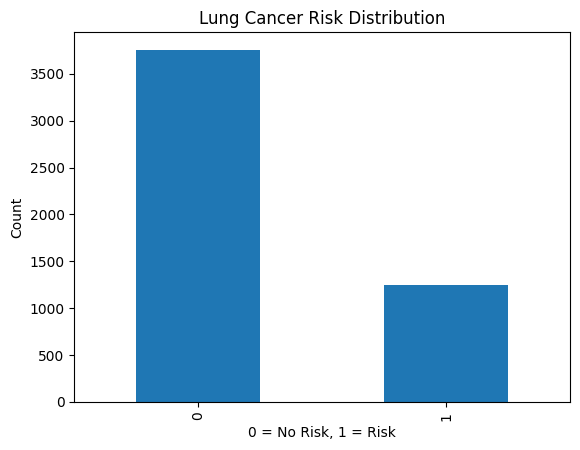

In [10]:
import matplotlib.pyplot as plt

# bar plot for target distribution

plt.figure()
df["lung_cancer_risk"].value_counts().plot(kind="bar")

plt.title("Lung Cancer Risk Distribution")
plt.xlabel("0 = No Risk, 1 = Risk")
plt.ylabel("Count")
plt.show()


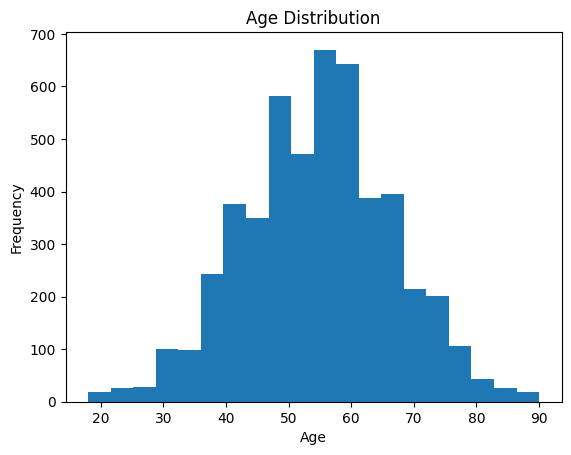

In [12]:
# plotting histogram to see how age is distributed

plt.figure()
plt.hist(df["age"], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()


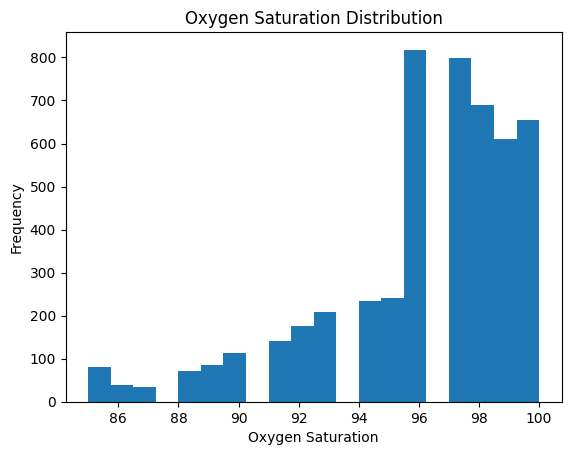

In [14]:
# checking distribution of oxygen saturation levels

plt.figure()
plt.hist(df["oxygen_saturation"], bins=20)

plt.title("Oxygen Saturation Distribution")
plt.xlabel("Oxygen Saturation")
plt.ylabel("Frequency")

plt.show()


In [19]:
# calculating correlation with target variable

corr = df.corr(numeric_only=True)["lung_cancer_risk"]

# sorting values in descending order
corr_sorted = corr.sort_values(ascending=False)

# selecting top 10 (excluding the target itself)
top_10 = corr_sorted[1:11]

print("Top 10 Features Correlated with Lung Cancer Risk:")
print(top_10)


Top 10 Features Correlated with Lung Cancer Risk:
pack_years               0.830688
crp_level                0.780422
xray_abnormal            0.748023
shortness_of_breath      0.659022
smoker                   0.630108
chronic_cough            0.629583
copd                     0.616377
age                      0.083533
family_history_cancer    0.063177
air_pollution_index      0.050072
Name: lung_cancer_risk, dtype: float64


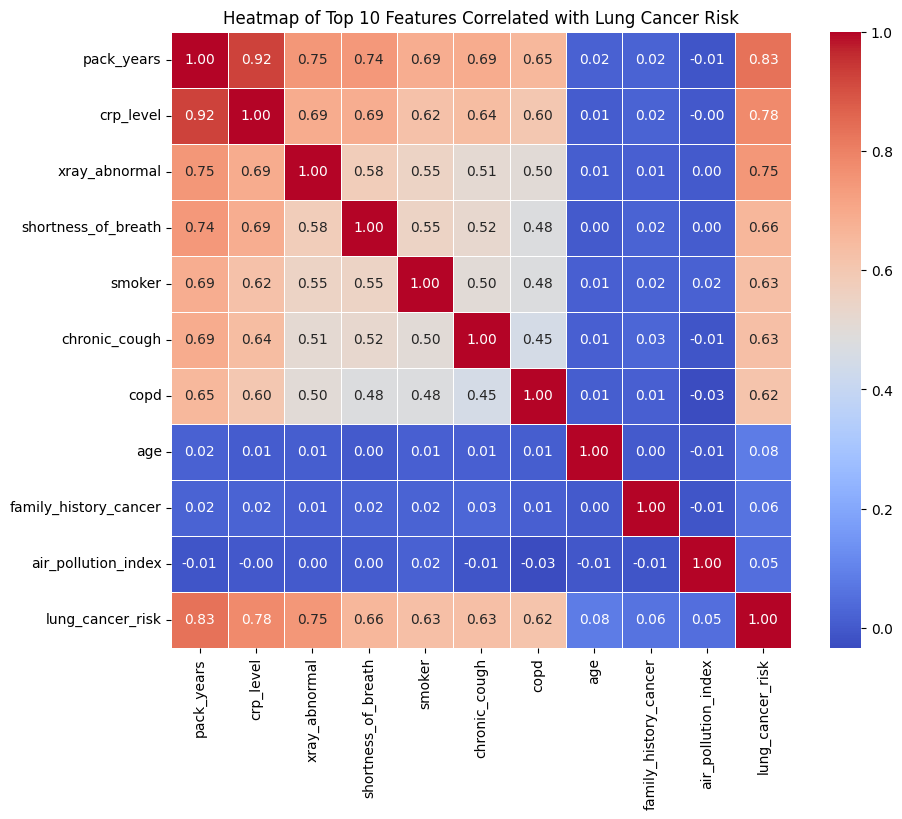

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# calculating correlation with target
corr = df.corr(numeric_only=True)["lung_cancer_risk"].sort_values(ascending=False)

# selecting top 10 features (excluding target itself)
top_10_features = corr.index[1:11]

# creating correlation matrix for only top 10 features
top_10_corr_matrix = df[top_10_features.tolist() + ["lung_cancer_risk"]].corr()

# plotting heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    top_10_corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Heatmap of Top 10 Features Correlated with Lung Cancer Risk")
plt.show()



<Figure size 640x480 with 0 Axes>

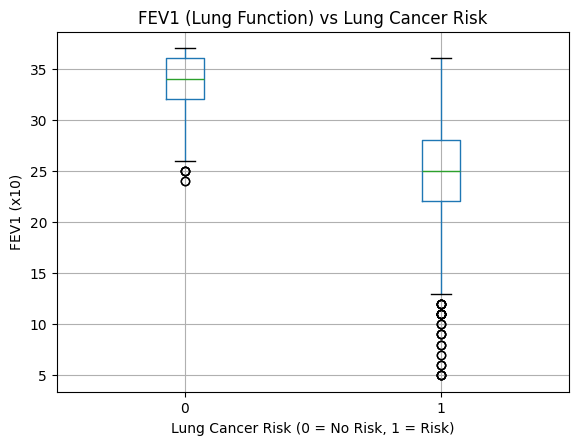

In [22]:
import matplotlib.pyplot as plt

# comparing lung function between people with and without cancer risk

plt.figure()

df.boxplot(column="fev1_x10", by="lung_cancer_risk")

plt.title("FEV1 (Lung Function) vs Lung Cancer Risk")
plt.suptitle("")   # removes automatic pandas title
plt.xlabel("Lung Cancer Risk (0 = No Risk, 1 = Risk)")
plt.ylabel("FEV1 (x10)")

plt.show()
